# Accuracy vs. Compute Tradeoff
The core deliverable: a Pareto scatter of compute cost vs. ranking quality across single-stage and cascade pipelines, plus supporting diagnostics (stage latency breakdown, BM25 first-stage recall@N, tail/head reward split).

In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
sys.path.insert(0, 'src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet('results/summary/all_runs.parquet')
df.head()

,exp_id,dataset,pipeline,stage_cutoffs,total_time_s,cpu_time_s,peak_vram_mb,mean_gpu_util_pct,energy_j,throughput_docs_per_s,timestamp,metric_name,k,value
0,biencoder_only,eurlex-4k,bi_encoder,10,6.55002,22.5,883.11377,35.365854,434.517382,590.074499,2026-06-20T20:12:47.132906,precision,1,0.105304
1,biencoder_only,eurlex-4k,bi_encoder,10,6.55002,22.5,883.11377,35.365854,434.517382,590.074499,2026-06-20T20:12:47.132906,precision,5,0.058991
2,biencoder_only,eurlex-4k,bi_encoder,10,6.55002,22.5,883.11377,35.365854,434.517382,590.074499,2026-06-20T20:12:47.132906,precision,10,0.044191
3,biencoder_only,eurlex-4k,bi_encoder,10,6.55002,22.5,883.11377,35.365854,434.517382,590.074499,2026-06-20T20:12:47.132906,ndcg,1,0.105304
4,biencoder_only,eurlex-4k,bi_encoder,10,6.55002,22.5,883.11377,35.365854,434.517382,590.074499,2026-06-20T20:12:47.132906,ndcg,5,0.072725


## 1. Pareto scatter: compute (s/doc) vs PS-nDCG@5

In [2]:
psndcg5 = df[(df.metric_name == 'psndcg') & (df.k == 5)][['exp_id', 'pipeline', 'value', 'total_time_s', 'energy_j']]
n_docs = df.groupby('exp_id')['total_time_s'].first().notna()  # placeholder, recompute below
throughput = df[['exp_id', 'throughput_docs_per_s']].drop_duplicates().set_index('exp_id')
psndcg5 = psndcg5.merge(throughput, on='exp_id')
psndcg5['s_per_doc'] = 1.0 / psndcg5['throughput_docs_per_s']
psndcg5

,exp_id,pipeline,value,total_time_s,energy_j,throughput_docs_per_s,s_per_doc
0,biencoder_only,bi_encoder,0.064040,6.550020,434.517382,590.074499,0.001695
1,biencoder_only_rag,bi_encoder,0.085547,6.580154,445.364995,587.372238,0.001702
2,bm25_bi_1000_100,bm25->bi_encoder,0.062394,8.491720,474.103453,455.149276,0.002197
3,bm25_bi_1000_100_rag,bm25->bi_encoder,0.085266,8.804066,508.596093,439.001725,0.002278
4,bm25_bi_cross_1000_100_10,bm25->bi_encoder->cross_encoder,0.051990,454.555294,39878.581474,8.502816,0.117608
5,bm25_bi_cross_1000_100_10_rag,bm25->bi_encoder->cross_encoder,0.055150,481.774130,42496.993508,8.022432,0.124650
6,bm25_only,bm25,0.114586,1.729754,26.268864,2234.421224,0.000448
7,bm25_only_rag,bm25,0.089578,2.174971,24.617129,1777.034814,0.000563
8,crossencoder_only,bm25->cross_encoder,0.066815,458.318832,40325.191406,8.432994,0.118582
9,crossencoder_only_rag,bm25->cross_encoder,0.063814,473.403324,42327.436860,8.164286,0.122485


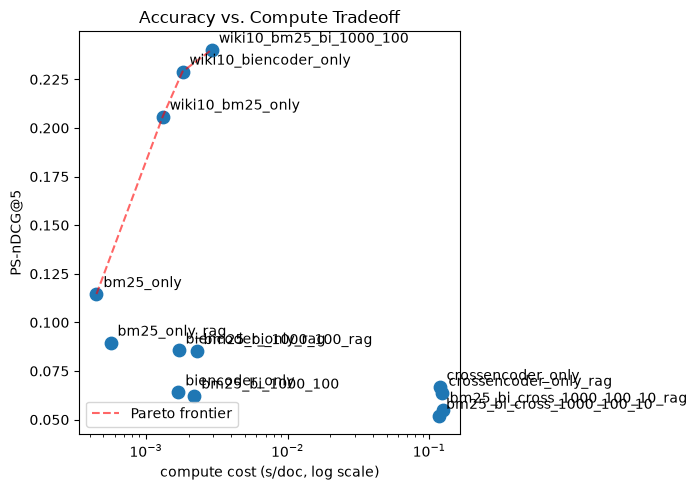

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(psndcg5['s_per_doc'], psndcg5['value'], s=80)
for _, row in psndcg5.iterrows():
    ax.annotate(row['exp_id'], (row['s_per_doc'], row['value']), textcoords='offset points', xytext=(5, 5))
ax.set_xscale('log')
ax.set_xlabel('compute cost (s/doc, log scale)')
ax.set_ylabel('PS-nDCG@5')
ax.set_title('Accuracy vs. Compute Tradeoff')

# Pareto frontier: sort by cost ascending, keep points whose value is a running max
frontier = psndcg5.sort_values('s_per_doc')
frontier = frontier[frontier['value'].cummax() == frontier['value']]
ax.plot(frontier['s_per_doc'], frontier['value'], 'r--', alpha=0.6, label='Pareto frontier')
ax.legend()
plt.tight_layout()
plt.savefig('reports/figures/04_pareto_tradeoff.png', dpi=150)
plt.show()

## 2. Stage latency breakdown

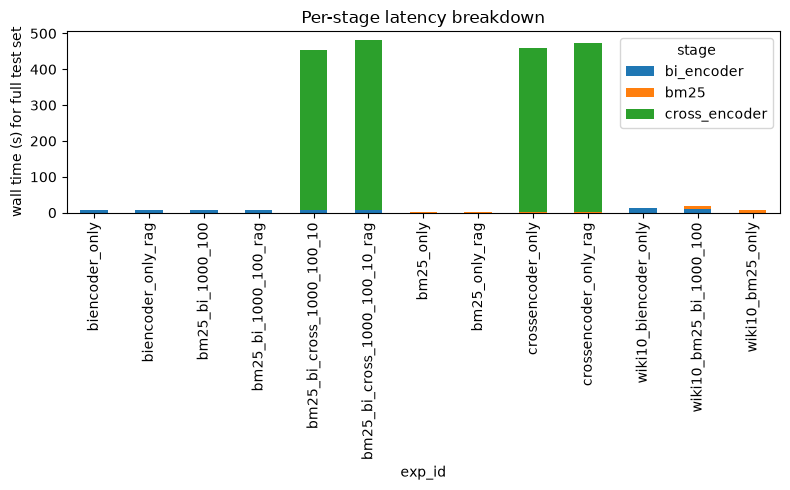

In [4]:
import json
from pathlib import Path

rows = []
for run_dir in sorted(Path('results/runs').iterdir()):
    res_path = run_dir / 'resources.json'
    if not res_path.exists():
        continue
    res = json.loads(res_path.read_text())
    for stage, stats in res['per_stage'].items():
        rows.append({'exp_id': run_dir.name, 'stage': stage, 'wall_time_s': stats['wall_time_s']})
stage_df = pd.DataFrame(rows)
pivot = stage_df.pivot(index='exp_id', columns='stage', values='wall_time_s').fillna(0)

ax = pivot.plot(kind='bar', stacked=True, figsize=(8, 5))
ax.set_ylabel('wall time (s) for full test set')
ax.set_title('Per-stage latency breakdown')
plt.tight_layout()
plt.savefig('reports/figures/05_stage_latency_breakdown.png', dpi=150)
plt.show()

## 3. BM25 first-stage recall@N (justifies cascade cutoffs)

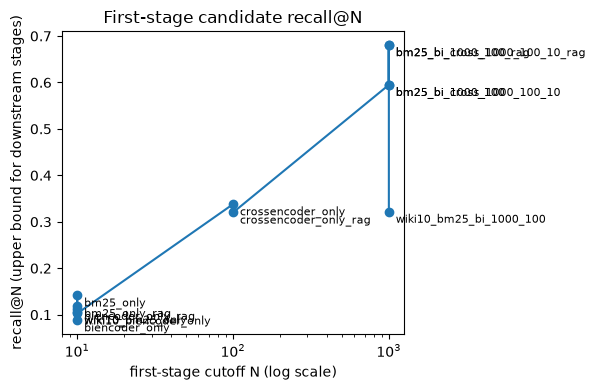

In [5]:
recall_df = df[df.metric_name == 'first_stage_recall'][['exp_id', 'k', 'value']].drop_duplicates().sort_values('k')
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall_df['k'], recall_df['value'], 'o-')
for _, row in recall_df.iterrows():
    ax.annotate(row['exp_id'], (row['k'], row['value']), textcoords='offset points', xytext=(5, -8), fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('first-stage cutoff N (log scale)')
ax.set_ylabel('recall@N (upper bound for downstream stages)')
ax.set_title('First-stage candidate recall@N')
plt.tight_layout()
plt.savefig('reports/figures/06_first_stage_recall.png', dpi=150)
plt.show()

## 4. Tail vs. head proportion in top-ranked predictions (paper Fig. 6 style)

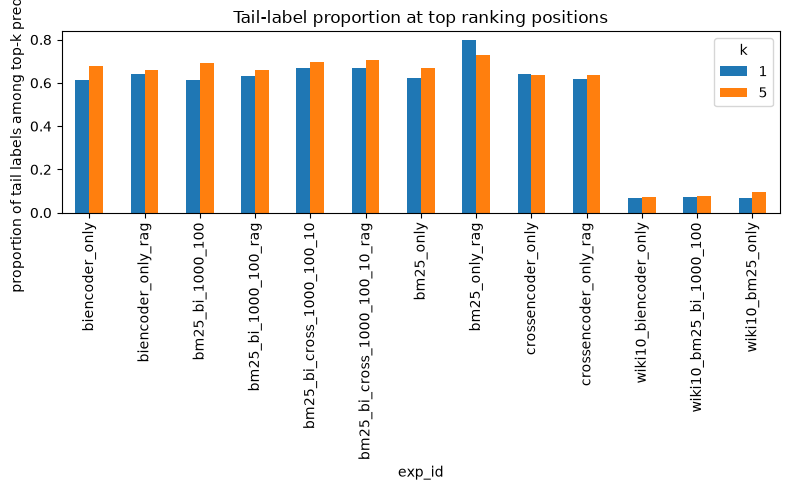

In [6]:
from cascade.data.loaders import load_processed
from cascade.eval.tail_head import compute_tail_label_ids, tail_proportion_at_k

train_df, test_df, labels_df, inv_propensity = load_processed('eurlex-4k')
tail_ids = compute_tail_label_ids(train_df, n_labels=len(labels_df))

rows = []
for run_dir in sorted(Path('results/runs').iterdir()):
    preds_path = run_dir / 'predictions.parquet'
    if not preds_path.exists():
        continue
    preds = pd.read_parquet(preds_path)['ranked_label_ids'].tolist()
    for k in (1, 5):
        rows.append({'exp_id': run_dir.name, 'k': k, 'tail_proportion': tail_proportion_at_k(preds, tail_ids, k)})
tail_df = pd.DataFrame(rows)

pivot = tail_df.pivot(index='exp_id', columns='k', values='tail_proportion')
ax = pivot.plot(kind='bar', figsize=(8, 5))
ax.set_ylabel('proportion of tail labels among top-k predictions')
ax.set_title('Tail-label proportion at top ranking positions')
plt.tight_layout()
plt.savefig('reports/figures/07_tail_head_proportion.png', dpi=150)
plt.show()